# AAAI-style Fontify quantity metric figures

Run this notebook once to generate both figure versions:

1. a two-column 2x2 figure for AAAI `figure*` usage;
2. a single-column vertical figure with PSNR, SSIM, MAE, and LPIPS stacked from top to bottom.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TWO_COLUMN_PDF = FIG_DIR / "fontify_quantity_metrics_aaai_v3.pdf"
TWO_COLUMN_SVG = FIG_DIR / "fontify_quantity_metrics_aaai_v3.svg"
SINGLE_COLUMN_PDF = FIG_DIR / "fontify_quantity_metrics_aaai_v2_vertical_single_col.pdf"
SINGLE_COLUMN_SVG = FIG_DIR / "fontify_quantity_metrics_aaai_v2_vertical_single_col.svg"

In [2]:
records = [
    {"quantity": 20, "PSNR": 7.7664, "SSIM": 0.6892, "MAE": 0.1907, "LPIPS": 0.3421},
    {"quantity": 50, "PSNR": 8.5984, "SSIM": 0.7053, "MAE": 0.1656, "LPIPS": 0.3216},
    {"quantity": 70, "PSNR": 9.1974, "SSIM": 0.7356, "MAE": 0.1473, "LPIPS": 0.2614},
    {"quantity": 100, "PSNR": 10.0143, "SSIM": 0.7535, "MAE": 0.1278, "LPIPS": 0.2507},
]

x = np.array([row["quantity"] for row in records], dtype=float)
x_labels = [f"{row['quantity']}%" for row in records]

metrics = [
    ("PSNR", "PSNR", "PSNR (dB)", "#0072B2"),
    ("SSIM", "SSIM", "SSIM", "#D55E00"),
    ("MAE", "MAE", "MAE", "#009E73"),
    ("LPIPS", "LPIPS", "LPIPS", "#CC79A7"),
]

value_formats = {
    "PSNR": "{:.4f}",
    "SSIM": "{:.4f}",
    "MAE": "{:.4f}",
    "LPIPS": "{:.4f}",
}

In [3]:
mpl.rcParams.update(
    {
        "font.family": "Times New Roman",
        "font.serif": ["Times New Roman"],
        "mathtext.fontset": "stix",
        "font.weight": "bold",
        "axes.titleweight": "bold",
        "axes.labelweight": "bold",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.7,
        "ytick.major.width": 0.7,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "axes.unicode_minus": False,
    }
)


def set_metric_ylim(ax, y, pad_ratio=0.24):
    y_min = float(y.min())
    y_max = float(y.max())
    y_pad = (y_max - y_min) * pad_ratio if y_max > y_min else max(abs(y_max) * 0.1, 0.01)
    ax.set_ylim(max(0, y_min - y_pad), y_max + y_pad)


def bold_axis_text(ax):
    ax.title.set_fontweight("bold")
    ax.xaxis.label.set_fontweight("bold")
    ax.yaxis.label.set_fontweight("bold")
    ax.xaxis.get_offset_text().set_fontweight("bold")
    ax.yaxis.get_offset_text().set_fontweight("bold")
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontweight("bold")


def style_metric_axis(ax):
    ax.grid(axis="y", linestyle="--", linewidth=0.45, alpha=0.45)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

## Version 1: two-column 2x2 figure

Saved two-column PDF: /Users/root1/Desktop/Fontify-main/figures/fontify_quantity_metrics_aaai_v3.pdf
Saved two-column SVG: /Users/root1/Desktop/Fontify-main/figures/fontify_quantity_metrics_aaai_v3.svg


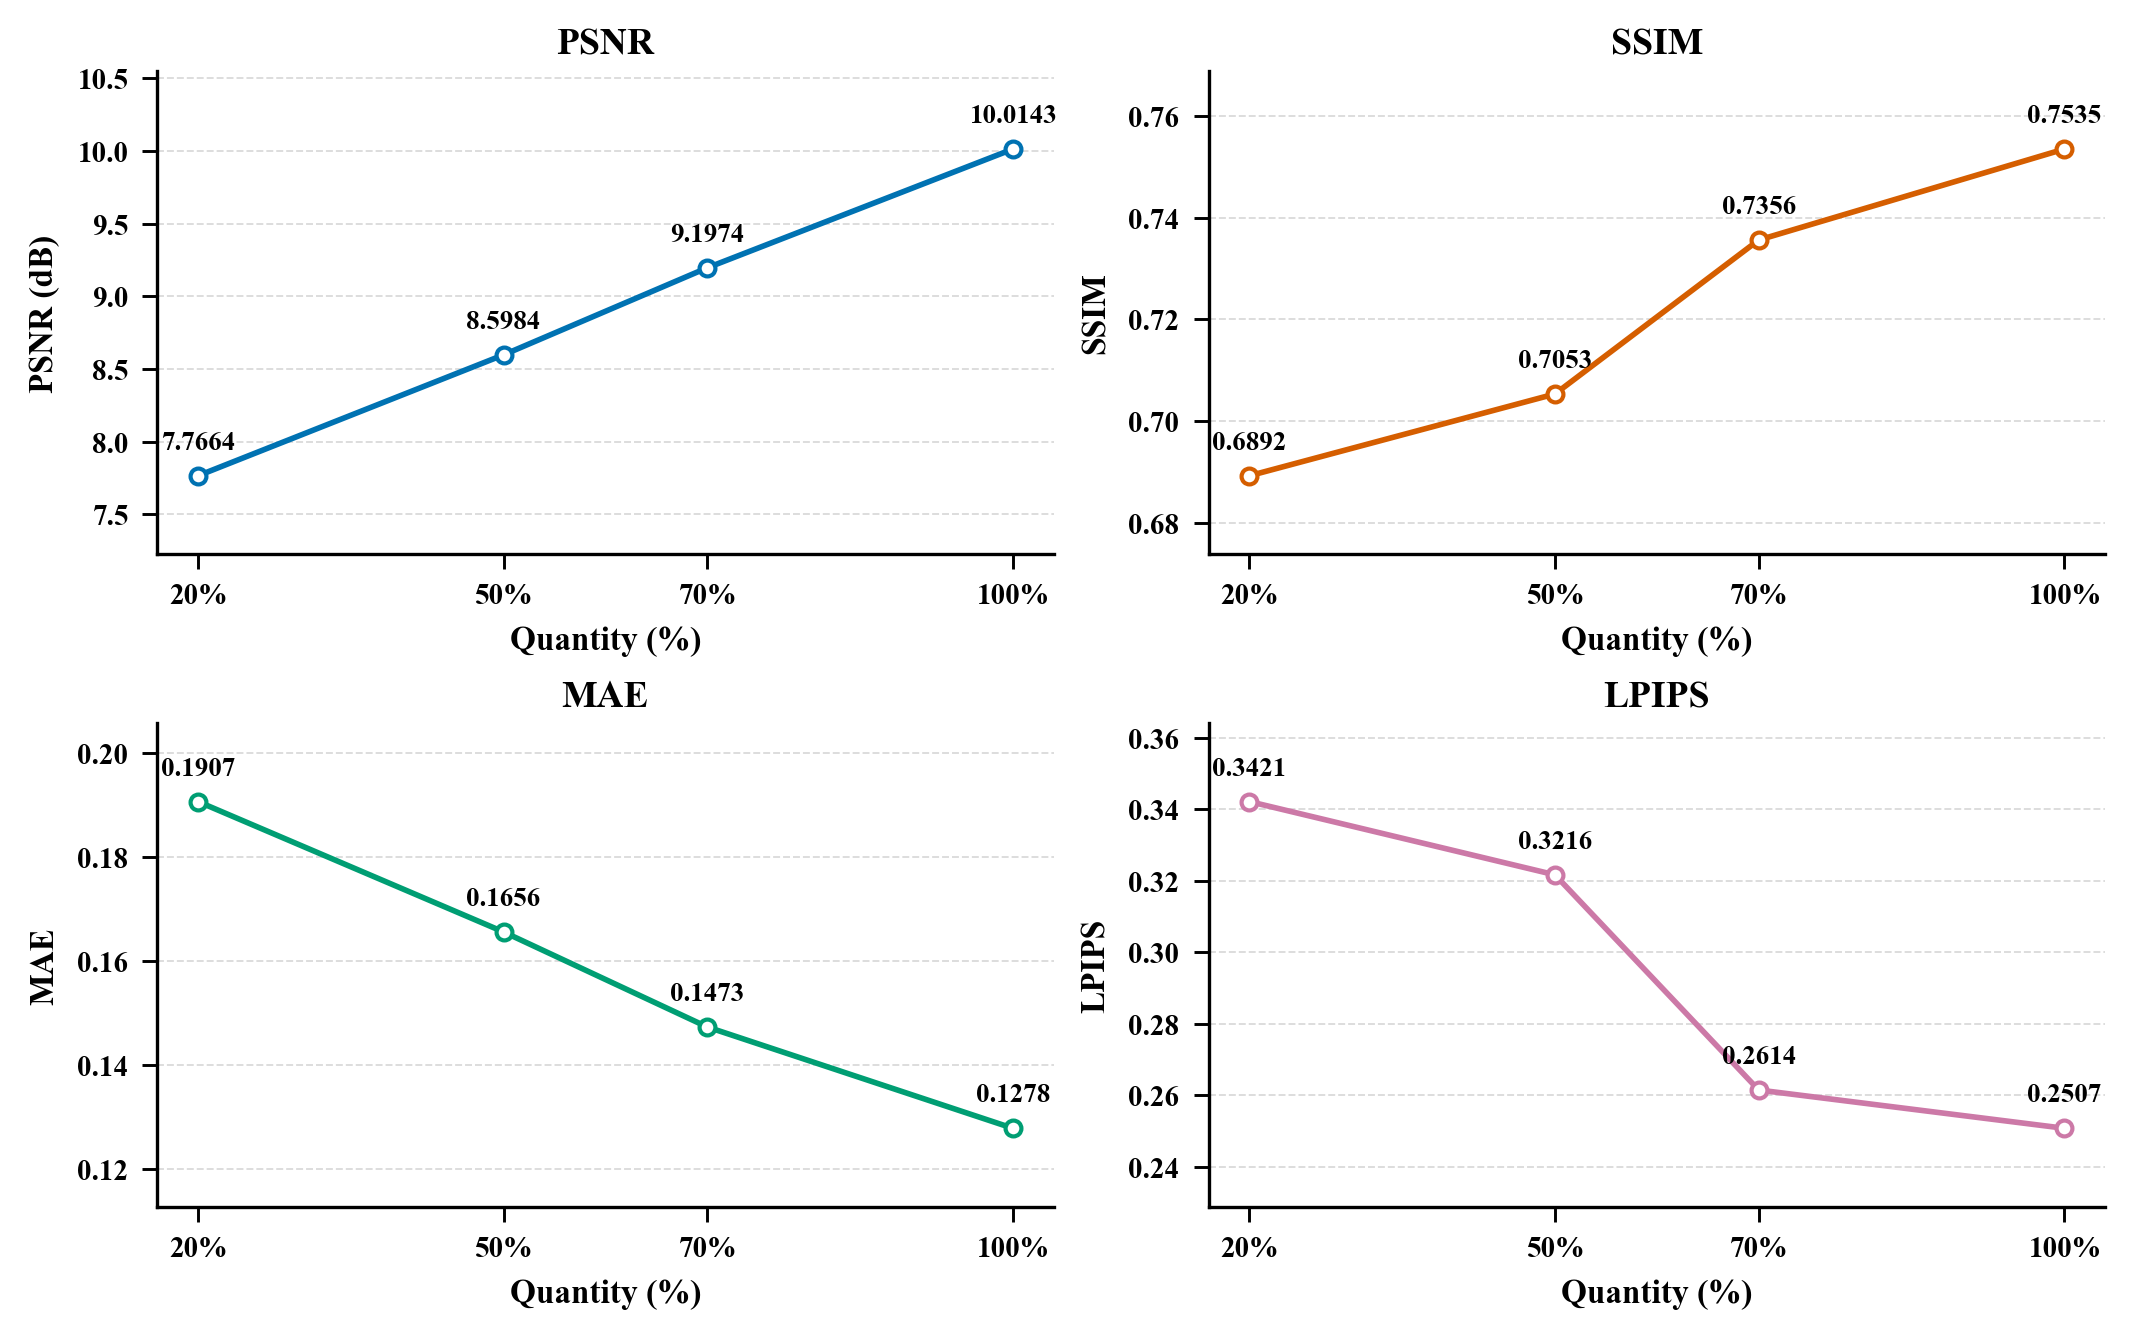

In [4]:
# Width is kept at AAAI two-column scale; height is compressed but readable.
fig, axes = plt.subplots(2, 2, figsize=(7.0, 4.35), constrained_layout=True)
axes = axes.ravel()

for ax, (metric_key, title, y_label, color) in zip(axes, metrics):
    y = np.array([row[metric_key] for row in records], dtype=float)

    ax.plot(
        x,
        y,
        color=color,
        marker="o",
        markersize=3.8,
        markerfacecolor="white",
        markeredgewidth=1.0,
        linewidth=1.35,
    )

    for xi, yi in zip(x, y):
        ax.annotate(
            value_formats[metric_key].format(yi),
            xy=(xi, yi),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=6.5,
            color="black",
            fontweight="bold",
        )

    ax.set_title(title, fontweight="bold", pad=4)
    ax.set_xlabel("Quantity (%)")
    ax.set_ylabel(y_label)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    set_metric_ylim(ax, y, pad_ratio=0.24)
    style_metric_axis(ax)
    bold_axis_text(ax)

fig.savefig(TWO_COLUMN_PDF, bbox_inches="tight")
fig.savefig(TWO_COLUMN_SVG, bbox_inches="tight")

print(f"Saved two-column PDF: {TWO_COLUMN_PDF.resolve()}")
print(f"Saved two-column SVG: {TWO_COLUMN_SVG.resolve()}")

plt.show()

## Version 2: single-column vertical figure

Saved single-column PDF: /Users/root1/Desktop/Fontify-main/figures/fontify_quantity_metrics_aaai_v2_vertical_single_col.pdf
Saved single-column SVG: /Users/root1/Desktop/Fontify-main/figures/fontify_quantity_metrics_aaai_v2_vertical_single_col.svg


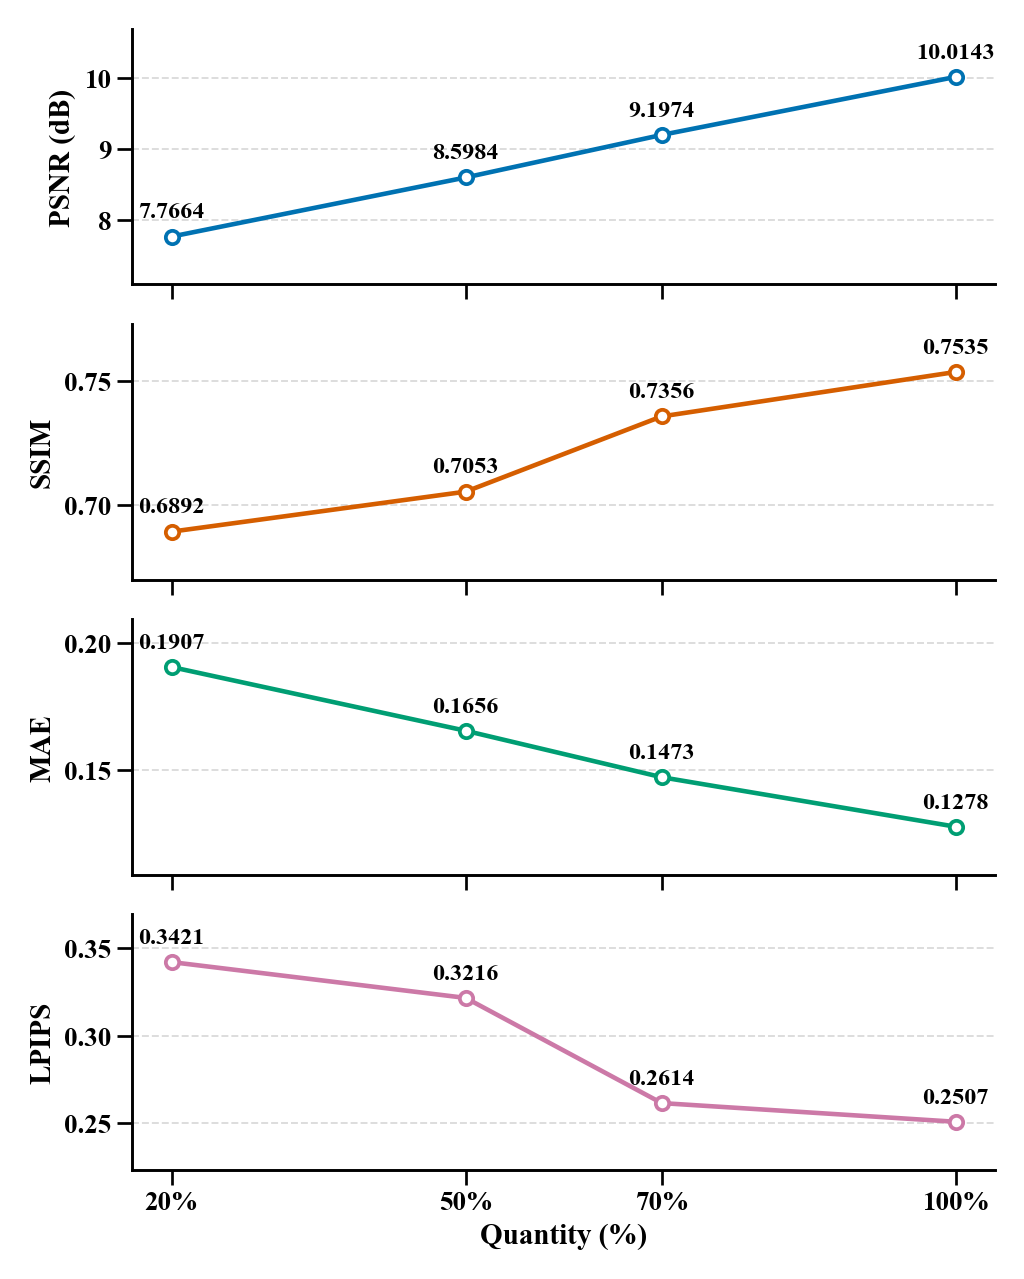

In [5]:
single_col_rc = {
    "axes.labelsize": 7,
    "xtick.labelsize": 6.5,
    "ytick.labelsize": 6.5,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.65,
    "ytick.major.width": 0.65,
}

with mpl.rc_context(single_col_rc):
    # AAAI single-column width is about 3.3 inches. Height is kept low while preserving labels.
    fig, axes = plt.subplots(4, 1, figsize=(3.3, 4.15), sharex=True, constrained_layout=True)

    for ax, (metric_key, title, y_label, color) in zip(axes, metrics):
        y = np.array([row[metric_key] for row in records], dtype=float)

        ax.plot(
            x,
            y,
            color=color,
            marker="o",
            markersize=3.2,
            markerfacecolor="white",
            markeredgewidth=0.9,
            linewidth=1.1,
        )

        for xi, yi in zip(x, y):
            ax.annotate(
                value_formats[metric_key].format(yi),
                xy=(xi, yi),
                xytext=(0, 3.4),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=5.8,
                color="black",
                fontweight="bold",
            )

        ax.set_ylabel(y_label, labelpad=2)
        ax.set_xlim(16, 104)
        ax.tick_params(axis="both", pad=1.5)
        set_metric_ylim(ax, y, pad_ratio=0.30)
        style_metric_axis(ax)
        bold_axis_text(ax)

    for ax in axes[:-1]:
        ax.tick_params(labelbottom=False)

    axes[-1].set_xlabel("Quantity (%)", labelpad=2)
    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(x_labels)
    for ax in axes:
        bold_axis_text(ax)

    fig.savefig(SINGLE_COLUMN_PDF, bbox_inches="tight")
    fig.savefig(SINGLE_COLUMN_SVG, bbox_inches="tight")

    print(f"Saved single-column PDF: {SINGLE_COLUMN_PDF.resolve()}")
    print(f"Saved single-column SVG: {SINGLE_COLUMN_SVG.resolve()}")

    plt.show()